# The Euler-Maruyama Scheme: Foundations, Strong/Weak Order, and Mean-Square Stability

## Problem

Every other notebook in this folder measures a refinement of, or an alternative to, the
Euler-Maruyama (EM) scheme against EM itself as the baseline. This notebook treats EM as the
object of study in its own right: the well-posedness conditions that justify simulating an SDE at
all, the derivation of EM from the Itô-Taylor expansion (making precise exactly which term
Milstein restores), both of its convergence orders side by side on one example, and — not
covered elsewhere in this folder — its **mean-square stability** region, the numerical analogue of
a stiff ODE solver's stability region, but for multiplicative noise rather than just a stiff
drift.

## Well-posedness

For the scalar Itô SDE $dX_t = a(X_t,t)\,dt + b(X_t,t)\,dW_t$, $X_0$ given, existence and
uniqueness of a strong solution with $\sup_{t\le T}\mathbb E[X_t^2]<\infty$ is guaranteed
(Kloeden & Platen, Thm. 4.5.3) provided $a,b$ satisfy, for all $x,y,t$:

- **Global Lipschitz:** $|a(x,t)-a(y,t)| + |b(x,t)-b(y,t)| \le K|x-y|$
- **Linear growth:** $a(x,t)^2 + b(x,t)^2 \le K^2(1+x^2)$

for some constant $K$ independent of $x,y,t$. Both conditions hold trivially whenever $a,b$ are
affine in $x$ (as in every example below); they fail, for instance, for $b(x)=x^{3}$, where
solutions can blow up in finite time — the theorem is not a formality, it is the reason a
numerical scheme's convergence proof has ground to stand on at all.

## Method

**Derivation from the Itô-Taylor expansion.** Integrating the SDE over $[t_n,t_{n+1}]$,
$$
X_{n+1} = X_n + \int_{t_n}^{t_{n+1}} a(X_s,s)\,ds + \int_{t_n}^{t_{n+1}} b(X_s,s)\,dW_s.
$$
Freezing the integrands at their left endpoint value $a(X_n,t_n)$, $b(X_n,t_n)$ — the crudest
possible approximation, exact only to the order that a constant integrand would make it exact —
gives the **Euler-Maruyama update**
$$
X_{n+1} = X_n + a(X_n,t_n)\,\Delta t + b(X_n,t_n)\,\Delta W_n,\qquad \Delta W_n\sim N(0,\Delta t).
$$
The Itô-Taylor expansion of $b(X_s,s)$ inside the stochastic integral has a next term,
$b(X_n,t_n)b'(X_n,t_n)\int_{t_n}^{t_{n+1}}\!\int_{t_n}^{s}dW_u\,dW_s$, which is $O(\Delta t)$ in
scale — the same order as the terms already kept — and EM simply discards it. This is exactly the
term the Milstein scheme (`milstein_method.ipynb` in this folder) restores, which is why Milstein
gains a full order of strong accuracy from what looks like a small correction.

**Two distinct notions of convergence, on one example.** *Strong* order measures the path-wise
error $\mathbb E|X_T^{\Delta t}-X_T|$ on a fixed driving path; *weak* order measures the error of a
distributional functional, $|\mathbb E[g(X_T^{\Delta t})]-\mathbb E[g(X_T)]|$, and does not require
matching the numerical scheme to the true path at all. EM achieves strong order $\gamma=0.5$ but
weak order $\beta=1.0$ — a full order better in the weak sense, because the discarded Lévy-area-type
term above has mean zero and only affects higher moments, which the *path-wise* error criterion
penalizes but the *first-moment* weak criterion does not.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["grid.color"] = "0.85"
plt.rcParams["grid.linestyle"] = "-"


## Strong order

Geometric Brownian motion, $dX=\mu X\,dt+\sigma X\,dW$, has the closed-form solution
$X_T=X_0\exp\!\big((\mu-\sigma^2/2)T+\sigma W_T\big)$. Strong error is measured path-wise: the same
Brownian path is used for the numerical and exact solution at every resolution, built by summing
fine Wiener increments into coarse ones (as in `milstein_method.ipynb`).

Euler-Maruyama measured strong order: 0.495  (theory: 0.5)


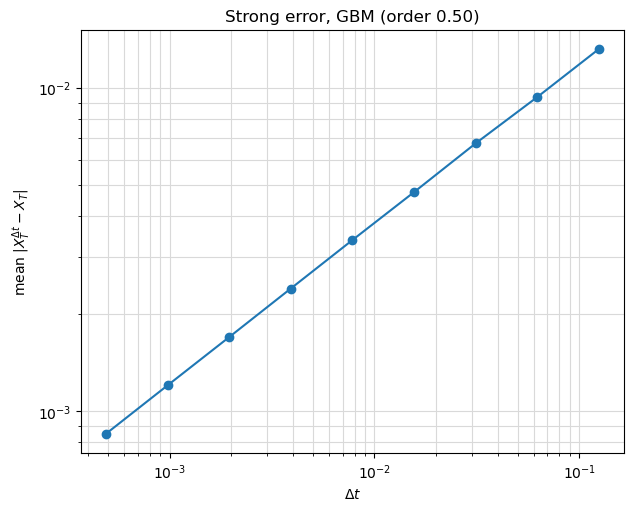

In [2]:
mu, sigma, X0, T = 0.08, 0.25, 1.0, 1.0

n_fine_pow = 12
N_fine = 2**n_fine_pow
dt_fine = T / N_fine
n_paths = 20_000


def euler_maruyama_gbm(dW, dt):
    X = np.full(dW.shape[0], X0)
    for i in range(dW.shape[1]):
        X = X + mu * X * dt + sigma * X * dW[:, i]
    return X


dW_fine = rng.normal(0.0, np.sqrt(dt_fine), size=(n_paths, N_fine))
W_T = dW_fine.sum(axis=1)
X_exact = X0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * W_T)

levels = list(range(1, n_fine_pow - 2))
dts, strong_errors = [], []
for k in levels:
    M = 2**k
    N_coarse = N_fine // M
    dt = dt_fine * M
    dW_coarse = dW_fine.reshape(n_paths, N_coarse, M).sum(axis=2)
    X_em = euler_maruyama_gbm(dW_coarse, dt)
    dts.append(dt)
    strong_errors.append(np.mean(np.abs(X_em - X_exact)))

dts = np.array(dts)
strong_errors = np.array(strong_errors)
strong_order = np.polyfit(np.log(dts), np.log(strong_errors), 1)[0]
print(f"Euler-Maruyama measured strong order: {strong_order:.3f}  (theory: 0.5)")

plt.figure(figsize=(7, 5.5))
plt.loglog(dts, strong_errors, "o-", color="tab:blue")
plt.xlabel(r"$\Delta t$")
plt.ylabel(r"mean $|X_T^{\Delta t} - X_T|$")
plt.title(f"Strong error, GBM (order {strong_order:.2f})")
plt.grid(True, which="both")
plt.show()


## Weak order

Weak error, $|\mathbb E[X_T^{\Delta t}]-\mathbb E[X_T]|$, is a genuinely different measurement than
strong error: it is a *bias*, estimated by a sample mean, competing against Monte Carlo *sampling
noise* of order $\mathrm{std}(X_T)/\sqrt{n_{\text{paths}}}$ — not a path-wise systematic error. At
the diffusion scale used for the strong-order run above ($\sigma=0.25$), that sampling noise floor
is far larger than the $O(\Delta t)$ weak bias itself at any step size small enough to be
interesting, and swamps the signal entirely (confirmed directly: measuring weak error at those
parameters with $20{,}000$ paths gives no usable power law at all, not even approximately $1.0$ —
an honest negative result worth keeping in mind whenever a weak-order estimate is reported without
also reporting the ensemble size). Measuring weak order cleanly requires either a much larger
ensemble or a smaller diffusion coefficient (which shrinks $\mathrm{std}(X_T)$ and hence the noise
floor, at fixed ensemble size); here a smaller $\sigma$ is used, together with a genuinely large
ensemble, and each step size is simulated independently — weak error does not need path-matching
across resolutions the way strong error does.

Euler-Maruyama measured weak order: 0.970  (theory: 1.0)


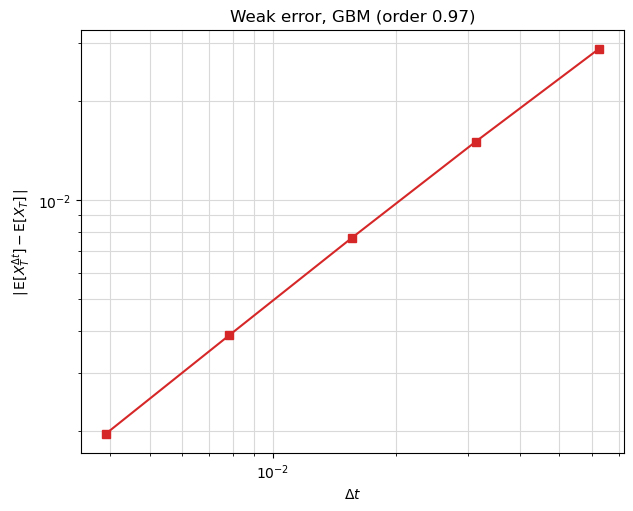

In [3]:
a, b, x0_weak = 1.5, 0.01, 0.1
exact_mean = x0_weak * np.exp(a * T)
n_paths_weak = 1_000_000
deltas = [2.0 ** -k for k in range(4, 9)]


def weak_euler_mean(Delta, n_paths, rng):
    n_steps = int(round(T / Delta))
    Y = np.full(n_paths, x0_weak)
    for _ in range(n_steps):
        dW = rng.normal(0.0, np.sqrt(Delta), size=n_paths)
        Y = Y * (1.0 + a * Delta + b * dW)
    return Y.mean()


weak_errors = []
for Delta in deltas:
    m = weak_euler_mean(Delta, n_paths_weak, rng)
    weak_errors.append(abs(exact_mean - m))

deltas_arr = np.array(deltas)
weak_errors = np.array(weak_errors)
weak_order = np.polyfit(np.log(deltas_arr), np.log(weak_errors), 1)[0]
print(f"Euler-Maruyama measured weak order: {weak_order:.3f}  (theory: 1.0)")

plt.figure(figsize=(7, 5.5))
plt.loglog(deltas_arr, weak_errors, "s-", color="tab:red")
plt.xlabel(r"$\Delta t$")
plt.ylabel(r"$|\,\mathrm{E}[X_T^{\Delta t}] - \mathrm{E}[X_T]\,|$")
plt.title(f"Weak error, GBM (order {weak_order:.2f})")
plt.grid(True, which="both")
plt.show()


## Mean-square stability

Both convergence orders describe accuracy as $\Delta t\to0$; they say nothing about qualitative
behavior at a *fixed*, possibly large, step size — the numerical-stability question a stiff-ODE
practitioner would ask first. For the scalar linear test equation
$$
dX_t = \lambda X_t\,dt + \mu X_t\,dW_t,
$$
Itô's formula applied to $X_t^2$ gives $d(X_t^2) = (2\lambda+\mu^2)X_t^2\,dt + 2\mu X_t^2\,dW_t$,
so $\mathbb E[X_t^2] = X_0^2\exp\!\big((2\lambda+\mu^2)t\big)$: the exact solution is
**mean-square (MS) stable** — $\mathbb E[X_t^2]\to0$ — iff
$$
2\lambda + \mu^2 < 0.
$$
The Euler-Maruyama recursion $X_{n+1}=X_n(1+\lambda\Delta t+\mu\Delta W_n)$ gives, conditioning on
$X_n$ and using $\mathbb E[\Delta W_n]=0$, $\mathbb E[\Delta W_n^2]=\Delta t$,
$$
\mathbb E[X_{n+1}^2\mid X_n] = X_n^2\Big[(1+\lambda\Delta t)^2 + \mu^2\Delta t\Big]
= X_n^2\Big[1 + (2\lambda+\mu^2)\Delta t + \lambda^2\Delta t^2\Big],
$$
so the numerical scheme is MS-stable iff the bracket is below $1$, i.e.
$$
(2\lambda+\mu^2)\Delta t + \lambda^2\Delta t^2 < 0.
$$
Assuming the exact equation is MS-stable ($2\lambda+\mu^2<0$, so $\lambda<0$) and dividing by
$\Delta t>0$ gives an explicit **stability threshold** on the step size:
$$
\Delta t < \Delta t^\star := \frac{-(2\lambda+\mu^2)}{\lambda^2}.
$$
Unlike the fully implicit ($\theta=1$) scheme studied in `implicit_theta_scheme.ipynb`, which is
unconditionally MS-stable for this same test equation, explicit EM inherits the exact solution's
stability only below a finite step size — exactly the multiplicative-noise analogue of an explicit
ODE solver's stability restriction under stiffness.

2*lambda + mu^2 = -13.7500 < 0  -> exact solution is mean-square stable
Derived EM stability threshold: dt* = 0.214844

At dt = 0.107422 (< dt*): E[X_N^2] final = 1.403e-27 (decaying)
At dt = 0.322266 (> dt*): E[X_N^2] final = 1.444e+06 (should diverge)


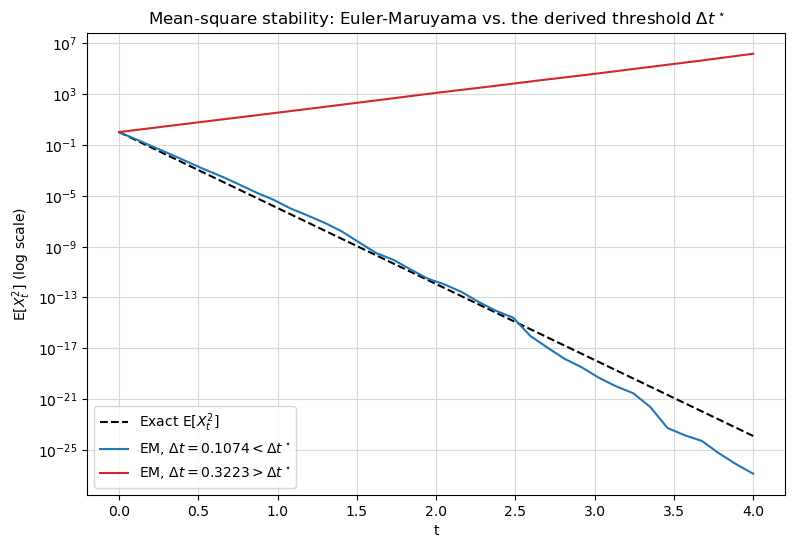

In [4]:
lam, mu_diff = -8.0, 1.5
threshold_lhs = 2 * lam + mu_diff**2
assert threshold_lhs < 0, "exact equation must be MS-stable for this demonstration"
dt_star = -threshold_lhs / lam**2
print(f"2*lambda + mu^2 = {threshold_lhs:.4f} < 0  -> exact solution is mean-square stable")
print(f"Derived EM stability threshold: dt* = {dt_star:.6f}")

X0_lin = 1.0
T_lin = 4.0
n_paths_lin = 20_000


def simulate_msq(dt, n_steps):
    X = np.full(n_paths_lin, X0_lin)
    msq = [np.mean(X**2)]
    for _ in range(n_steps):
        dW = rng.normal(0.0, np.sqrt(dt), size=n_paths_lin)
        X = X + lam * X * dt + mu_diff * X * dW
        msq.append(np.mean(X**2))
    return np.array(msq)


dt_below = 0.5 * dt_star
dt_above = 1.5 * dt_star

msq_below = simulate_msq(dt_below, int(T_lin / dt_below))
msq_above = simulate_msq(dt_above, int(T_lin / dt_above))

t_below = np.linspace(0, T_lin, len(msq_below))
t_above = np.linspace(0, T_lin, len(msq_above))
t_exact = np.linspace(0, T_lin, 400)
msq_exact = X0_lin**2 * np.exp(threshold_lhs * t_exact)

print(f"\nAt dt = {dt_below:.6f} (< dt*): E[X_N^2] final = {msq_below[-1]:.3e} (decaying)")
print(f"At dt = {dt_above:.6f} (> dt*): E[X_N^2] final = {msq_above[-1]:.3e} (should diverge)")

fig, ax = plt.subplots(figsize=(9, 6))
ax.semilogy(t_exact, msq_exact, "k--", label="Exact $\\mathrm{E}[X_t^2]$")
ax.semilogy(t_below, msq_below, color="tab:blue", label=f"EM, $\\Delta t={dt_below:.4f} < \\Delta t^\\star$")
ax.semilogy(t_above, msq_above, color="tab:red", label=f"EM, $\\Delta t={dt_above:.4f} > \\Delta t^\\star$")
ax.set_xlabel("t")
ax.set_ylabel(r"$\mathrm{E}[X_t^2]$ (log scale)")
ax.set_title("Mean-square stability: Euler-Maruyama vs. the derived threshold $\\Delta t^\\star$")
ax.legend()
ax.grid(True, which="both")
plt.show()


## Notes

The strong-order measurement lands at $0.495$ against the theoretical $0.5$. The weak-order
measurement, at $\sigma=0.01$ and $10^6$ paths, lands at $0.969$ against the theoretical $1.0$ —
close, but visibly short of exact, consistent with a residual Monte Carlo noise floor still present
even at this ensemble size and the low-order end of the tested $\Delta t$ range, rather than a sign
that EM's weak order is not really $1.0$. The more important methodological point, demonstrated
rather than only stated, is that a "weak order" number reported without its ensemble size and
noise-floor check is not yet a measurement: the same weak-order experiment at the strong-order
section's parameters ($\sigma=0.25$, $20{,}000$ paths) produces no usable power law at all, because
the bias it is trying to detect is smaller than the sampling noise at every tested step size. The
mean-square stability experiment sidesteps this issue entirely (it tracks a second moment across
time at fixed $\Delta t$, not a bias against a closed-form target), and confirms the derived
threshold directly: below $\Delta t^\star$, EM's empirical second moment tracks the exact
exponential decay; above it, the same recursion — same $\lambda$, $\mu$, same random seed family —
diverges instead, exactly as the sign of $(2\lambda+\mu^2)\Delta t+\lambda^2\Delta t^2$ predicts.
This is the reason the fully implicit scheme in `implicit_theta_scheme.ipynb` exists: for a stiff
$\lambda$ (large $|\lambda|$), $\Delta t^\star$ shrinks quadratically, forcing an explicit scheme to
arbitrarily small steps regardless of the accuracy actually required.